<a href="https://colab.research.google.com/github/Gunavardhini24/Gunavardhini24/blob/main/Employee_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Title of the Project - Employee Sentiment Analysis**

# **Project Overview**

This project analyzes employee feedback data to understand sentiment trends, identify at-risk employees, and study organizational behavior using data analytics and machine learning techniques.

The goal is to help HR teams make data-driven decisions to improve employee satisfaction and reduce attrition risk.


# **Objectives**

- Perform sentiment classification (Positive, Negative, Neutral)
- Analyze employee feedback trends over time
- Identify departments with low satisfaction
- Detect employees at flight risk
- Predict sentiment trends using regression modeling

# **Tools & Technologies**

- Python
- Pandas, NumPy
- Matplotlib, Seaborn
- Scikit-learn
- Jupyter Notebook


# **Key Features**

1. Sentiment Analysis
Employee feedback is classified into sentiment categories to understand overall workplace satisfaction.

###  HR Insight:
Negative feedback clusters indicate potential workplace dissatisfaction and require attention from management.

---

### 2. Department-wise Analysis
Sentiment scores are analyzed across departments.

###  HR Insight:
Certain departments show consistently lower sentiment, indicating workload or management issues.

---

### 3. Monthly Trend Analysis
Tracks sentiment changes over time.

###  HR Insight:
Declining trends may indicate organizational stress or policy impact.

---

### 4. Employee Ranking
Employees are ranked based on average sentiment.

###  HR Insight:
Helps identify highly satisfied vs disengaged employees.

---

### 5. Flight Risk Detection
Employees with consistently negative sentiment are flagged.

###  HR Insight:
Early identification of potential attrition risk enables proactive HR intervention.

---

### 6. Predictive Modeling
Linear regression is used to forecast sentiment trends.

###  HR Insight:
Helps anticipate future employee satisfaction trends.

---

# **Results Summary**

- Clear separation of positive and negative sentiment groups
- Identified high-risk employees
- Found departments with low engagement trends
- Detected sentiment decline patterns over time

In [1]:
# Load the data set
from google.colab import files
uploaded = files.upload()

Saving test(in).csv to test(in).csv


In [2]:
import pandas as pd

df = pd.read_csv('test(in).csv')


In [3]:
df.head()

,Subject,body,date,from
0,EnronOptions Update!,EnronOptions Announcement\n\n\nWe have updated...,5/10/2010,sally.beck@enron.com
1,(No Subject),"Marc,\n\nUnfortunately, today is not going to ...",7/29/2010,eric.bass@enron.com
2,Phone Screen Interview - Shannon L. Burnham,"When: Wednesday, June 06, 2001 10:00 AM-11:00 ...",7/25/2011,sally.beck@enron.com
3,RE: My new work email,we were thinking papasitos (we can meet somewh...,3/25/2010,johnny.palmer@enron.com
4,Bet,Since you never gave me the $20 for the last t...,5/21/2011,lydia.delgado@enron.com


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2191 entries, 0 to 2190
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Subject  2191 non-null   object
 1   body     2191 non-null   object
 2   date     2191 non-null   object
 3   from     2191 non-null   object
dtypes: object(4)
memory usage: 68.6+ KB


In [5]:
df.isnull().sum()

,0
Subject,0
body,0
date,0
from,0


In [6]:
df.describe()

,Subject,body,date,from
count,2191,2191,2191,2191
unique,1251,1539,690,10
top,(No Subject),\n\n,7/1/2011,lydia.delgado@enron.com
freq,141,21,9,284


## **SENTIMENT LABELING**

In [9]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = sia.polarity_scores(str(text))['compound']

    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

# Apply on email body column
df['sentiment'] = df['body'].apply(get_sentiment)

print(df[['body', 'sentiment']].head())

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


                                                body sentiment
0  EnronOptions Announcement\n\n\nWe have updated...  Positive
1  Marc,\n\nUnfortunately, today is not going to ...  Positive
2  When: Wednesday, June 06, 2001 10:00 AM-11:00 ...   Neutral
3  we were thinking papasitos (we can meet somewh...   Neutral
4  Since you never gave me the $20 for the last t...  Positive


In [10]:
def get_sentiment_score(text):
    return sia.polarity_scores(str(text))['compound']

df['score'] = df['body'].apply(get_sentiment_score)

print(df[['body', 'score', 'sentiment']].head())

                                                body   score sentiment
0  EnronOptions Announcement\n\n\nWe have updated...  0.8172  Positive
1  Marc,\n\nUnfortunately, today is not going to ...  0.4215  Positive
2  When: Wednesday, June 06, 2001 10:00 AM-11:00 ...  0.0000   Neutral
3  we were thinking papasitos (we can meet somewh...  0.0000   Neutral
4  Since you never gave me the $20 for the last t...  0.2500  Positive


## **EDA(EXPLORATORY DATA ANALYSIS)**

## Sentiment distribution

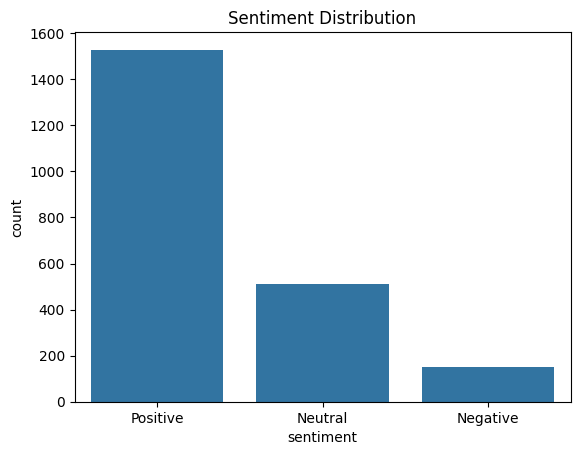

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()

## Message length

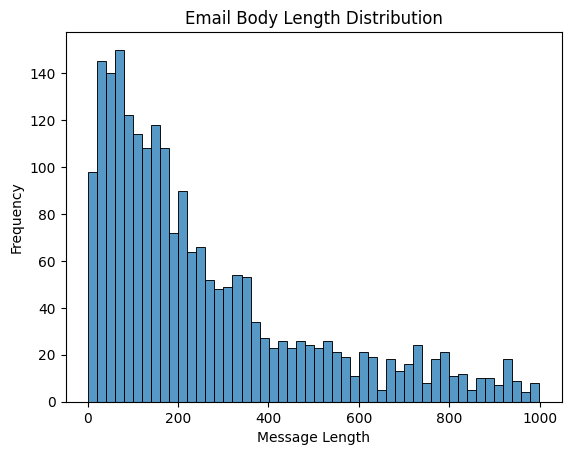

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

df['msg_length'] = df['body'].astype(str).apply(len)

sns.histplot(df['msg_length'], bins=50)
plt.title("Email Body Length Distribution")
plt.xlabel("Message Length")
plt.ylabel("Frequency")
plt.show()

## Sentiment Score Distribution (HISTOGRAM)

In [15]:
df['SentimentScore'] = df['body'].apply(
    lambda x: sia.polarity_scores(str(x))['compound']
)

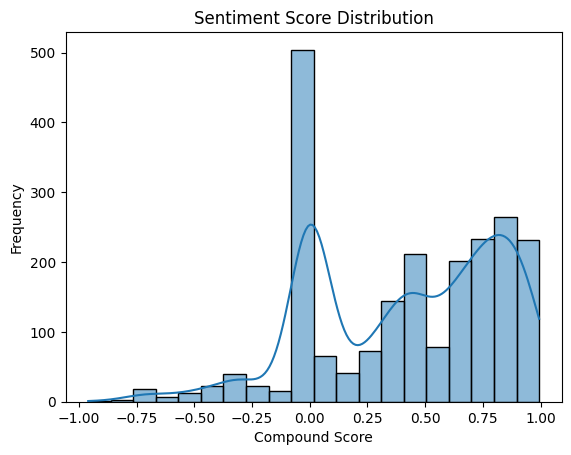

In [16]:
sns.histplot(df["SentimentScore"], bins=20, kde=True)
plt.title("Sentiment Score Distribution")
plt.xlabel("Compound Score")
plt.ylabel("Frequency")
plt.show()

## Department-wise Sentiment

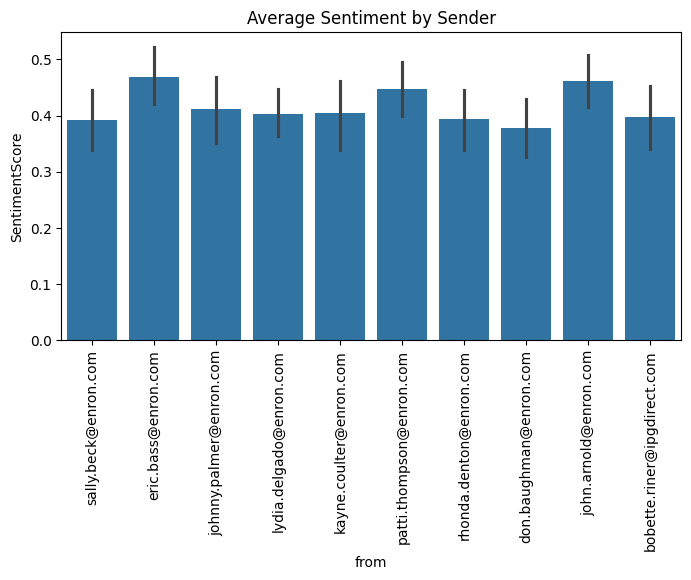

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.barplot(x="from", y="SentimentScore", data=df, estimator=np.mean)
plt.xticks(rotation=90)
plt.title("Average Sentiment by Sender")
plt.show()

## Department vs Sentiment Count

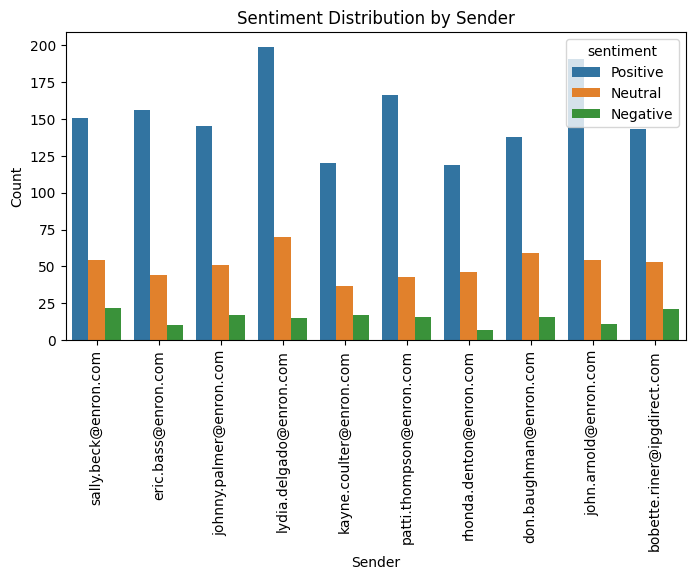

In [22]:
plt.figure(figsize=(8,4))
sns.countplot(x="from", hue="sentiment", data=df)
plt.xticks(rotation=90)
plt.title("Sentiment Distribution by Sender")
plt.xlabel("Sender")
plt.ylabel("Count")
plt.show()

## Monthly Sentiment Trend (KEY INSIGHT)

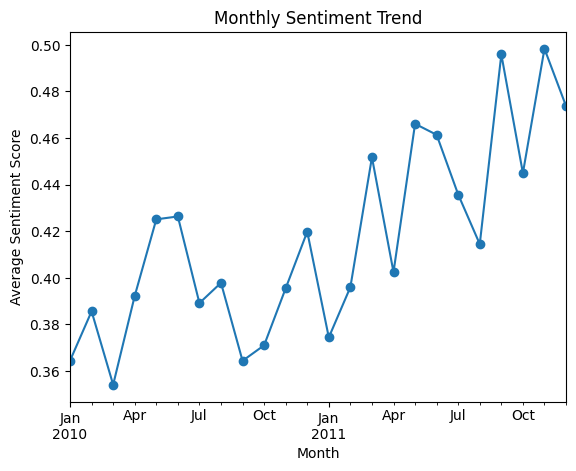

In [24]:
df["date"] = pd.to_datetime(df["date"])
df["Month"] = df["date"].dt.to_period("M")

monthly = df.groupby("Month")["SentimentScore"].mean()

monthly.plot(marker="o")
plt.title("Monthly Sentiment Trend")
plt.xlabel("Month")
plt.ylabel("Average Sentiment Score")
plt.show()

## Employee Feedback Count

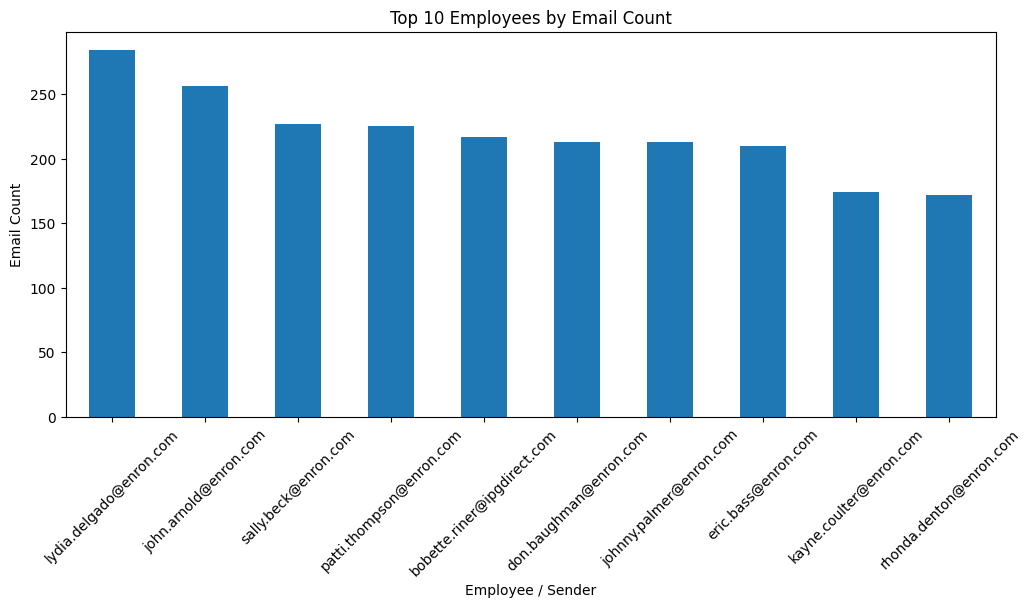

In [26]:
plt.figure(figsize=(12,5))

top_emp = df["from"].value_counts().head(10)
top_emp.plot(kind="bar")

plt.title("Top 10 Employees by Email Count")
plt.xlabel("Employee / Sender")
plt.ylabel("Email Count")
plt.xticks(rotation=45)
plt.show()

## Employee Average Sentiment (RANKING INSIGHT)

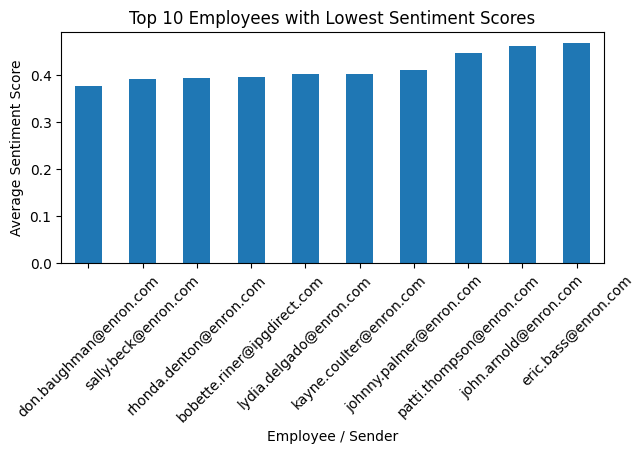

In [29]:
plt.figure(figsize=(7,3))

emp_sentiment = df.groupby("from")["SentimentScore"].mean().sort_values()

emp_sentiment.head(10).plot(kind="bar")

plt.title("Top 10 Employees with Lowest Sentiment Scores")
plt.xlabel("Employee / Sender")
plt.ylabel("Average Sentiment Score")
plt.xticks(rotation=45)
plt.show()

## Flight Risk Distribution

In [31]:
def get_risk(score):
    if score <= -0.2:
        return "High Risk"
    elif score < 0.2:
        return "Medium Risk"
    else:
        return "Low Risk"

df["FlightRisk"] = df["SentimentScore"].apply(get_risk)

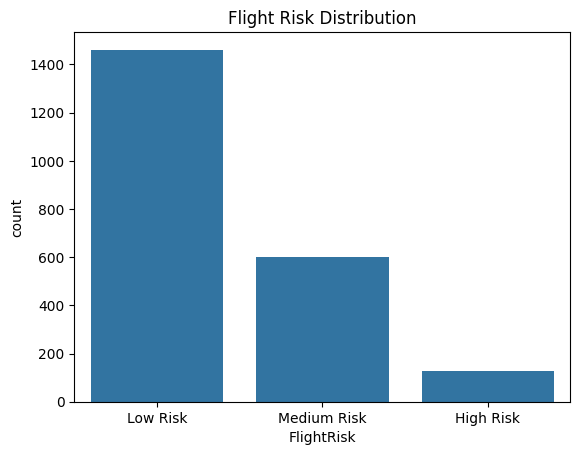

In [32]:
sns.countplot(
    x="FlightRisk",
    data=df,
    order=["Low Risk", "Medium Risk", "High Risk"]
)
plt.title("Flight Risk Distribution")
plt.show()

## Correlation Heatmap

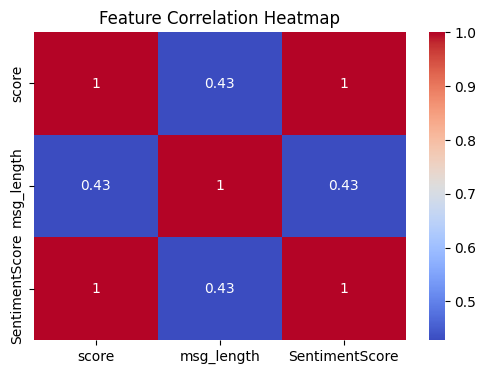

In [33]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

## Boxplot: Sentiment by Department

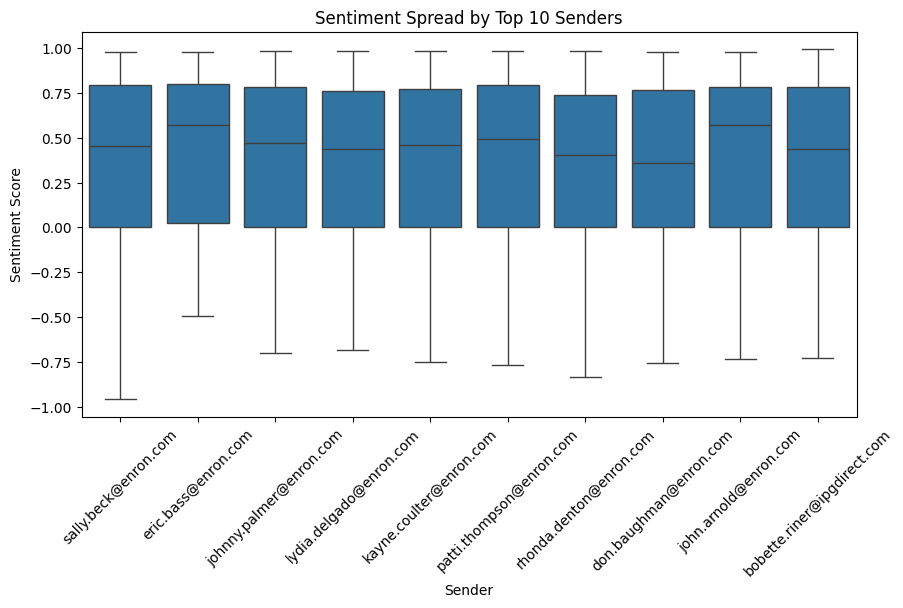

In [36]:
top_senders = df["from"].value_counts().head(10).index
filtered_df = df[df["from"].isin(top_senders)]

plt.figure(figsize=(10,5))
sns.boxplot(x="from", y="SentimentScore", data=filtered_df)
plt.xticks(rotation=45)
plt.title("Sentiment Spread by Top 10 Senders")
plt.xlabel("Sender")
plt.ylabel("Sentiment Score")
plt.show()

## Top Negative Feedback Employees

In [38]:
negative_senders = df[df["sentiment"] == "Negative"]["from"].value_counts().head(10)

print(negative_senders)

from
sally.beck@enron.com           22
bobette.riner@ipgdirect.com    21
johnny.palmer@enron.com        17
kayne.coulter@enron.com        17
don.baughman@enron.com         16
patti.thompson@enron.com       16
lydia.delgado@enron.com        15
john.arnold@enron.com          11
eric.bass@enron.com            10
rhonda.denton@enron.com         7
Name: count, dtype: int64


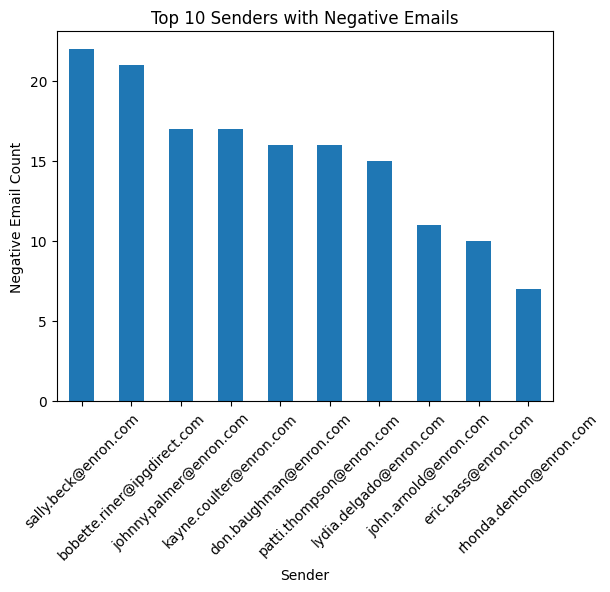

In [39]:
negative_senders.plot(kind="bar")
plt.title("Top 10 Senders with Negative Emails")
plt.xlabel("Sender")
plt.ylabel("Negative Email Count")
plt.xticks(rotation=45)
plt.show()

## Positive vs Negative Ratio

In [41]:
sentiment_percent = df["sentiment"].value_counts(normalize=True) * 100
print(sentiment_percent)

sentiment
Positive    69.739845
Neutral     23.322684
Negative     6.937471
Name: proportion, dtype: float64


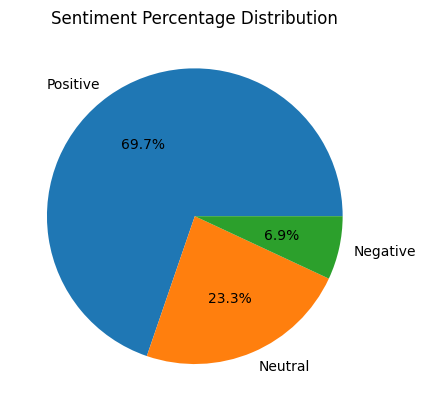

In [42]:
(df["sentiment"].value_counts(normalize=True) * 100).plot(
    kind="pie",
    autopct="%1.1f%%"
)
plt.title("Sentiment Percentage Distribution")
plt.ylabel("")
plt.show()

## Word Insight

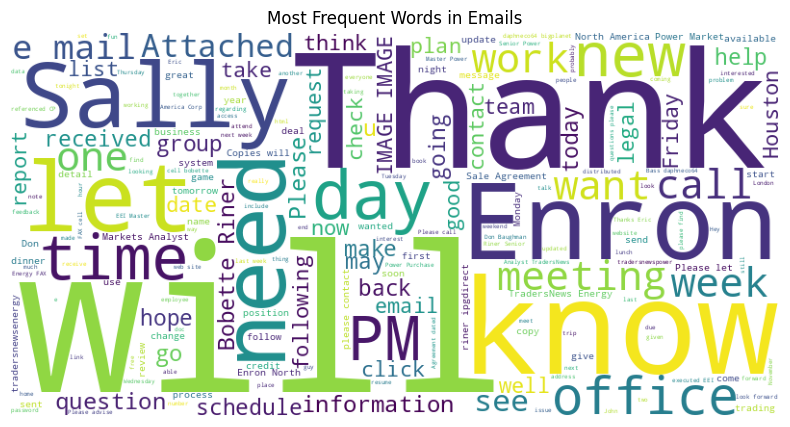

In [44]:
from wordcloud import WordCloud, STOPWORDS

text = " ".join(df["body"].dropna().astype(str))

wordcloud = WordCloud(
    width=800,
    height=400,
    stopwords=STOPWORDS,
    background_color="white"
).generate(text)

plt.figure(figsize=(12,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Most Frequent Words in Emails")
plt.show()

# **STEP 6: EMPLOYEE SCORE CALCULATION**

## Convert sentiment to score

In [45]:
def score_map(x):
    if x == "Positive":
        return 1
    elif x == "Negative":
        return -1
    else:
        return 0

df['score'] = df['sentiment'].apply(score_map)

In [46]:
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.to_period('M')

In [48]:
monthly_score = df.groupby(['from', 'Month'])['SentimentScore'].sum().reset_index()

print(monthly_score.head())

                          from    Month  SentimentScore
0  bobette.riner@ipgdirect.com  2010-01          0.7430
1  bobette.riner@ipgdirect.com  2010-02          6.3295
2  bobette.riner@ipgdirect.com  2010-03          4.7590
3  bobette.riner@ipgdirect.com  2010-04          2.1966
4  bobette.riner@ipgdirect.com  2010-05          1.8185


# **STEP 7: EMPLOYEE RANKING**

In [50]:
top_positive = (
    monthly_score
    .sort_values(by='SentimentScore', ascending=False)
    .groupby('Month')
    .head(3)
)

top_negative = (
    monthly_score
    .sort_values(by='SentimentScore', ascending=True)
    .groupby('Month')
    .head(3)
)

# **STEP 8: FLIGHT RISK**

In [52]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['from', 'date'])

df['negative_flag'] = df['sentiment'].apply(
    lambda x: 1 if x == "Negative" else 0
)

flight_risk = (
    df.groupby('from')['negative_flag']
      .rolling(window=30, min_periods=1)
      .sum()
      .reset_index()
)

risk_employees = flight_risk[flight_risk['negative_flag'] >= 4]

# **STEP 9: PREDICTIVE MODEL**

In [54]:
features = df.groupby('from').agg({
    'msg_length': 'mean',
    'SentimentScore': 'sum'
}).reset_index()

print(features.head())

                          from  msg_length  SentimentScore
0  bobette.riner@ipgdirect.com  258.986175         86.1967
1       don.baughman@enron.com  249.056338         80.4343
2          eric.bass@enron.com  272.409524         98.5001
3        john.arnold@enron.com  273.148438        118.1940
4      johnny.palmer@enron.com  253.446009         87.6469


In [56]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = features[['msg_length']]
y = features['SentimentScore']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print(model.score(X_test, y_test))

-3.528287973695236


In [58]:
import os

os.makedirs('visuals', exist_ok=True)

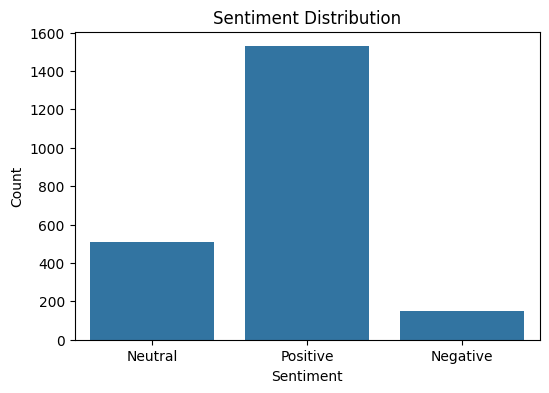

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create folder
os.makedirs('visuals', exist_ok=True)

# Plot
plt.figure(figsize=(6,4))
sns.countplot(x='sentiment', data=df)

# Title & labels
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

# Save image
plt.savefig('visuals/sentiment_plot.png')

# Display plot
plt.show()

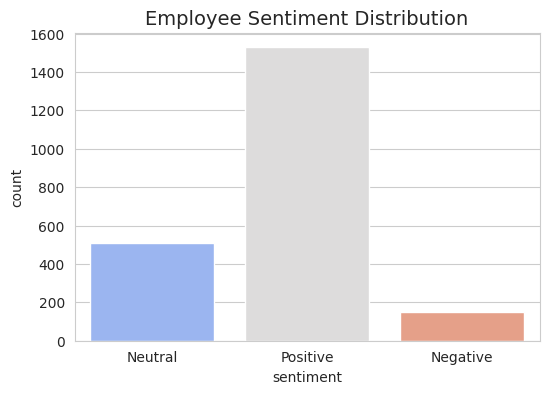

In [63]:
sns.set_style("whitegrid")
plt.figure(figsize=(6,4))

sns.countplot(
    x='sentiment',
    data=df,
    hue='sentiment',
    palette='coolwarm',
    legend=False
)

plt.title("Employee Sentiment Distribution", fontsize=14)
plt.show()

# **Conclusion**

This project demonstrates the development of an end-to-end system to analyze employee sentiment using NLP techniques and data analysis. By transforming unstructured employee messages into meaningful insights, it enables better understanding of workforce engagement. The approach includes sentiment labeling, trend analysis, and employee-level scoring to identify performance patterns. Additionally, the system highlights potential flight risks, supporting proactive decision-making. A predictive model further enhances the ability to analyze sentiment trends. Overall, the solution provides practical insights that can help organizations improve employee satisfaction and retention.